In [1]:
!pip install -q transformers torch sklearn-crfsuite spacy
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import json


train_file_path = "/kaggle/input/datasets/ajaykumarmorasa/da-genia/genia/genia_train_dev.json"

with open(train_file_path) as f:
    train_data = json.load(f)

print("Train samples:", len(train_data))
print(train_data[0])

Train samples: 16692
{'tokens': ['IL-2', 'gene', 'expression', 'and', 'NF-kappa', 'B', 'activation', 'through', 'CD28', 'requires', 'reactive', 'oxygen', 'production', 'by', '5-lipoxygenase', '.'], 'entities': [{'start': 14, 'end': 15, 'type': 'protein'}, {'start': 4, 'end': 6, 'type': 'protein'}, {'start': 0, 'end': 2, 'type': 'DNA'}, {'start': 8, 'end': 9, 'type': 'protein'}], 'relations': {}, 'org_id': 'ge/train/0001'}


In [3]:

test_file_path = "/kaggle/input/datasets/ajaykumarmorasa/da-genia/genia/genia_test_context.json"

with open(test_file_path) as f:
    test_data = json.load(f)

print("Test samples:", len(test_data))
print(test_data[0])

Test samples: 1854
{'tokens': ['There', 'is', 'a', 'single', 'methionine', 'codon-initiated', 'open', 'reading', 'frame', 'of', '1,458', 'nt', 'in', 'frame', 'with', 'a', 'homeobox', 'and', 'a', 'CAX', 'repeat', ',', 'and', 'the', 'open', 'reading', 'frame', 'is', 'predicted', 'to', 'encode', 'a', 'protein', 'of', '51,659', 'daltons.'], 'entities': [{'start': 16, 'end': 17, 'type': 'DNA'}, {'start': 4, 'end': 9, 'type': 'DNA'}, {'start': 24, 'end': 27, 'type': 'DNA'}, {'start': 19, 'end': 21, 'type': 'DNA'}], 'relations': {}, 'org_id': 'ge/test/0001', 'pos': ['PRON', 'AUX', 'DET', 'ADJ', 'NOUN', 'VERB', 'ADJ', 'NOUN', 'NOUN', 'ADP', 'NUM', 'PART', 'ADP', 'NOUN', 'ADP', 'DET', 'NOUN', 'CCONJ', 'DET', 'PROPN', 'NOUN', ',', 'CCONJ', 'DET', 'ADJ', 'NOUN', 'NOUN', 'AUX', 'VERB', 'PART', 'VERB', 'DET', 'NOUN', 'ADP', 'NUM', 'NOUN'], 'ltokens': [], 'rtokens': []}


In [4]:
def is_overlap(e1, e2):
    return not (e1['end'] <= e2['start'] or e2['end'] <= e1['start'])

In [ ]:
def create_layers(entities):
    
    entities = sorted(entities, key=lambda x: (x['end'] - x['start']))

    layers = []

    for e in entities:
        placed = False

        for layer in layers:
            if not any(is_overlap(e, existing) for existing in layer):
                layer.append(e)
                placed = True
                break

        if not placed:
            layers.append([e])

    return layers

In [6]:
def create_bio_labels(tokens, layer_entities):
    labels = ["O"] * len(tokens)

    for e in layer_entities:
        start, end, etype = e["start"], e["end"], e["type"]

        labels[start] = "B-" + etype

        for i in range(start + 1, end):
            labels[i] = "I-" + etype

    return labels

In [7]:
def get_word_shape(word):
    shape = ""
    for ch in word:
        if ch.isupper():
            shape += "X"
        elif ch.islower():
            shape += "x"
        elif ch.isdigit():
            shape += "d"
        else:
            shape += ch
    return shape

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import spacy

MODEL_NAME = "dmis-lab/biobert-base-cased-v1.1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)

bert_model.to(device)
bert_model.eval()


nlp = spacy.load("en_core_web_sm")

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:
embedding_cache = {}

def get_bert_embeddings(tokens):
    key = tuple(tokens)

    if key in embedding_cache:
        return embedding_cache[key]

    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding=False
    )

    word_ids = encoding.word_ids()

    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs=bert_model(**encoding)

    hidden_states = outputs.last_hidden_state[0].detach().cpu()
    hidden_size = hidden_states.shape[-1]

    word_embeddings = [np.zeros(hidden_size, dtype=np.float32) for _ in tokens]

    from collections import defaultdict
    grouped = defaultdict(list)

    for idx, word_id in enumerate(word_ids):
        if word_id is not None and word_id < len(tokens):
            grouped[word_id].append(hidden_states[idx].numpy())

    for word_id, vecs in grouped.items():
        word_embeddings[word_id] = np.mean(vecs, axis=0).astype(np.float32)

    token_embeddings = np.array(word_embeddings, dtype=np.float32)

    embedding_cache[key] = token_embeddings
    return token_embeddings

In [ ]:
def extract_features(tokens):
    features = []

    bert_vectors = get_bert_embeddings(tokens)

    
    doc = nlp(" ".join(tokens))
    pos_tags = [token.pos_ for token in doc]

   
    if len(pos_tags) < len(tokens):
        pos_tags.extend(["X"] * (len(tokens) - len(pos_tags)))
    elif len(pos_tags) > len(tokens):
        pos_tags = pos_tags[:len(tokens)]

    biomedical_keywords = {
        "protein", "gene", "dna", "rna", "cell",
        "receptor", "factor", "kinase", "enzyme",
        "alpha", "beta", "interleukin"
    }

    for i, word in enumerate(tokens):
        lower_word = word.lower()

        feature = {
            "lower": lower_word,
            "word_shape": get_word_shape(word),

            "is_upper": word.isupper(),
            "is_title": word.istitle(),
            "is_digit": word.isdigit(),

            "pos": pos_tags[i],

            "prefix1": word[:1],
            "prefix2": word[:2],
            "prefix3": word[:3],

            "suffix1": word[-1:],
            "suffix2": word[-2:],
            "suffix3": word[-3:],
            "suffix4": word[-4:],

            "len": len(word),

            "has_hyphen": "-" in word,
            "has_digit": any(c.isdigit() for c in word),
            "has_upper_inside": any(c.isupper() for c in word[1:]),

            "contains_alpha": "alpha" in lower_word,
            "contains_beta": "beta" in lower_word,

            "is_biomedical_keyword": lower_word in biomedical_keywords,
        }

       
        if i < len(bert_vectors):
            vec = bert_vectors[i]
        else:
            vec = np.zeros(bert_vectors.shape[1], dtype=np.float32)

        for j, val in enumerate(vec[:128]):
            feature[f"bert_{j}"] = float(val)

        
        for offset in [-2, -1, 1, 2]:
            pos = i + offset
            if 0 <= pos < len(tokens):
                neighbor = tokens[pos]
                feature[f"context_{offset}_word"] = neighbor
                feature[f"context_{offset}_shape"] = get_word_shape(neighbor)
            else:
                feature[f"context_{offset}_PAD"] = True

        features.append(feature)

    return features

In [ ]:
def prepare_layered_data(dataset, max_layers=3, limit=None):
    X_layers = [[] for _ in range(max_layers)]
    y_layers = [[] for _ in range(max_layers)]

    if limit is not None:
        dataset = dataset[:limit]

    for idx, sample in enumerate(dataset):
        if idx % 100 == 0:
            print(f"Processing sample {idx}/{len(dataset)}")

        tokens = sample["tokens"]
        entities = sample["entities"]

        layers = create_layers(entities)
        features = extract_features(tokens)

        
        repeat = 2 if len(layers) >= 2 else 1

        for _ in range(repeat):
            for i in range(min(len(layers), max_layers)):
                labels = create_bio_labels(tokens, layers[i])

                X_layers[i].append(features)
                y_layers[i].append(labels)

    print("Prepared dataset for", len(X_layers), "layers")
    return X_layers, y_layers

In [12]:
X_train_layers, y_train_layers = prepare_layered_data(train_data)
X_test_layers, y_test_layers = prepare_layered_data(test_data)

Processing sample 0/16692
Processing sample 100/16692
Processing sample 200/16692
Processing sample 300/16692
Processing sample 400/16692
Processing sample 500/16692
Processing sample 600/16692
Processing sample 700/16692
Processing sample 800/16692
Processing sample 900/16692
Processing sample 1000/16692
Processing sample 1100/16692
Processing sample 1200/16692
Processing sample 1300/16692
Processing sample 1400/16692
Processing sample 1500/16692
Processing sample 1600/16692
Processing sample 1700/16692
Processing sample 1800/16692
Processing sample 1900/16692
Processing sample 2000/16692
Processing sample 2100/16692
Processing sample 2200/16692
Processing sample 2300/16692
Processing sample 2400/16692
Processing sample 2500/16692
Processing sample 2600/16692
Processing sample 2700/16692
Processing sample 2800/16692
Processing sample 2900/16692
Processing sample 3000/16692
Processing sample 3100/16692
Processing sample 3200/16692
Processing sample 3300/16692
Processing sample 3400/166

In [13]:
from sklearn_crfsuite import CRF

models = []

for i in range(len(X_train_layers)):
    if len(X_train_layers[i]) == 0:
        continue

    if len(set(sum(y_train_layers[i], []))) <= 1:
        continue

    print(f"Training Layer {i+1}")

    crf = CRF(
        algorithm="lbfgs",
        c1=0.2 + i * 0.08,
        c2=0.2 + i * 0.08,
        max_iterations=100,
        all_possible_transitions=True
    )

    crf.fit(X_train_layers[i], y_train_layers[i])
    models.append(crf)

Training Layer 1
Training Layer 2
Training Layer 3


In [14]:
def bio_to_spans(tokens, labels, layer_id):
    spans = []
    i = 0

    while i < len(labels):
        if labels[i].startswith("B-"):
            entity_type = labels[i][2:]
            start = i
            i += 1

            while i < len(labels) and labels[i].startswith("I-"):
                i += 1

            end = i

            spans.append({
                "text": " ".join(tokens[start:end]),
                "start": start,
                "end": end,
                "type": entity_type,
                "layer": layer_id
            })
        else:
            i += 1

    return spans

In [15]:
def combine_all_layers(tokens, models):
    features = extract_features(tokens)
    final_entities = []

    for i, model in enumerate(models):
        pred = model.predict_single(features)
        spans = bio_to_spans(tokens, pred, i + 1)
        final_entities.extend(spans)

    return final_entities

In [16]:
test_sample = test_data[0]
tokens = test_sample["tokens"]

final_output = combine_all_layers(tokens, models)

print("TOKENS:")
print(tokens)

print("\nFINAL NESTED OUTPUT:")
for entity in final_output:
    print(entity)

TOKENS:
['There', 'is', 'a', 'single', 'methionine', 'codon-initiated', 'open', 'reading', 'frame', 'of', '1,458', 'nt', 'in', 'frame', 'with', 'a', 'homeobox', 'and', 'a', 'CAX', 'repeat', ',', 'and', 'the', 'open', 'reading', 'frame', 'is', 'predicted', 'to', 'encode', 'a', 'protein', 'of', '51,659', 'daltons.']

FINAL NESTED OUTPUT:
{'text': 'codon-initiated open reading frame', 'start': 5, 'end': 9, 'type': 'DNA', 'layer': 1}
{'text': 'CAX repeat', 'start': 19, 'end': 21, 'type': 'DNA', 'layer': 1}
{'text': 'open reading frame', 'start': 24, 'end': 27, 'type': 'DNA', 'layer': 1}


In [17]:
def spans_overlap(e1, e2):

    if "sid" in e1 and "sid" in e2 and e1["sid"] != e2["sid"]:
        return False

    return not (e1["end"] <= e2["start"] or e2["end"] <= e1["start"])

In [18]:
def get_true_spans(sample):
    tokens = sample["tokens"]
    entities = []

    for e in sample["entities"]:
        entities.append({
            "text": " ".join(tokens[e["start"]:e["end"]]),
            "start": e["start"],
            "end": e["end"],
            "type": e["type"]
        })

    return entities

In [19]:
def compute_overall_f1(true_entities, pred_entities):
    def span_key(e):

        if "sid" in e:
            return (e["sid"], e["start"], e["end"], e["type"])
        return (e["start"], e["end"], e["type"])

    true_set = {span_key(e) for e in true_entities}
    pred_set = {span_key(e) for e in pred_entities}

    tp = len(true_set & pred_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

In [20]:
def get_nested_entities(entities):
    nested = []

    for i in range(len(entities)):
        for j in range(len(entities)):
            if i != j and spans_overlap(entities[i], entities[j]):
                nested.append(entities[i])
                break

    return nested

In [21]:
def compute_nested_f1(true_entities, pred_entities):
    true_nested = get_nested_entities(true_entities)
    pred_nested = get_nested_entities(pred_entities)

    return compute_overall_f1(true_nested, pred_nested)

In [22]:
def get_ndt_entities(entities):
    ndt = []

    for i in range(len(entities)):
        for j in range(len(entities)):
            if i != j and spans_overlap(entities[i], entities[j]):
                if entities[i]["type"] != entities[j]["type"]:
                    ndt.append(entities[i])
                    break

    return ndt

In [23]:
def get_nst_entities(entities):
    nst = []

    for i in range(len(entities)):
        for j in range(len(entities)):
            if i != j and spans_overlap(entities[i], entities[j]):
                if entities[i]["type"] == entities[j]["type"]:
                    nst.append(entities[i])
                    break

    return nst

In [24]:
def compute_ndt_f1(true_entities, pred_entities):
    true_ndt = get_ndt_entities(true_entities)
    pred_ndt = get_ndt_entities(pred_entities)

    return compute_overall_f1(true_ndt, pred_ndt)


def compute_nst_f1(true_entities, pred_entities):
    true_nst = get_nst_entities(true_entities)
    pred_nst = get_nst_entities(pred_entities)

    return compute_overall_f1(true_nst, pred_nst)

In [25]:
all_true_entities = []
all_pred_entities = []

for idx, sample in enumerate(test_data):
    tokens = sample["tokens"]

    true_entities = get_true_spans(sample)
    pred_entities = combine_all_layers(tokens, models)

    for e in true_entities:
        e["sid"] = idx
    for e in pred_entities:
        e["sid"] = idx

    all_true_entities.extend(true_entities)
    all_pred_entities.extend(pred_entities)

_, _, overall_f1 = compute_overall_f1(all_true_entities, all_pred_entities)
_, _, nested_f1 = compute_nested_f1(all_true_entities, all_pred_entities)
_, _, ndt_f1 = compute_ndt_f1(all_true_entities, all_pred_entities)
_, _, nst_f1 = compute_nst_f1(all_true_entities, all_pred_entities)

print("===== FINAL TEST DATASET METRICS =====")
print("Overall F1:", overall_f1)
print("Nested F1:", nested_f1)
print("NDT F1:", ndt_f1)
print("NST F1:", nst_f1)

===== FINAL TEST DATASET METRICS =====
Overall F1: 0.7254021648497361
Nested F1: 0.3632303634957769
NDT F1: 0.4229508146655335
NST F1: 0.2213836430245877


In [74]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


def spans_to_labels(tokens, entities):
    labels = ["O"] * len(tokens)
    
    for ent in entities:
        start = ent.get("start")
        end = ent.get("end")

        label = ent.get("label") or ent.get("type") or ent.get("entity")
        
        if start is None or end is None or label is None:
            continue
        
        for i in range(start, min(end, len(tokens))):
            labels[i] = label
    
    return labels


y_true = []
y_pred = []

for idx, sample in enumerate(test_data):
    tokens = sample["tokens"]
    
    true_entities = get_true_spans(sample)
    pred_entities = combine_all_layers(tokens, models)
    
    true_labels = spans_to_labels(tokens, true_entities)
    pred_labels = spans_to_labels(tokens, pred_entities)
    
    y_true.extend(true_labels)
    y_pred.extend(pred_labels)




print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Classification Report:

              precision    recall  f1-score   support

         DNA       0.69      0.77      0.72      2794
           O       0.96      0.96      0.96     37683
         RNA       0.69      0.58      0.63       199
   cell_line       0.81      0.74      0.78      1137
   cell_type       0.80      0.79      0.79      1160
     protein       0.84      0.79      0.81      5206

    accuracy                           0.92     48179
   macro avg       0.80      0.77      0.78     48179
weighted avg       0.92      0.92      0.92     48179



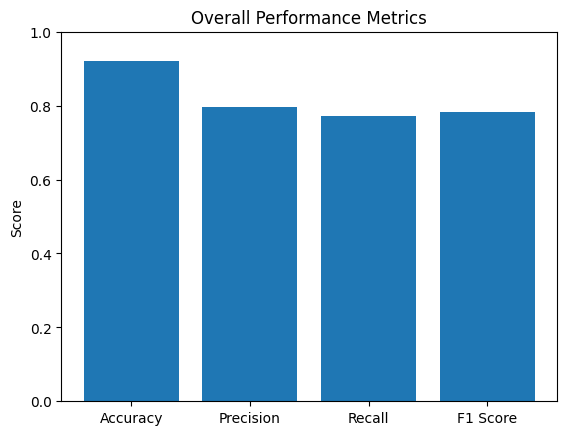

In [29]:
metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, average='macro'),
    "Recall": recall_score(y_true, y_pred, average='macro'),
    "F1 Score": f1_score(y_true, y_pred, average='macro')
}

plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.title("Overall Performance Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

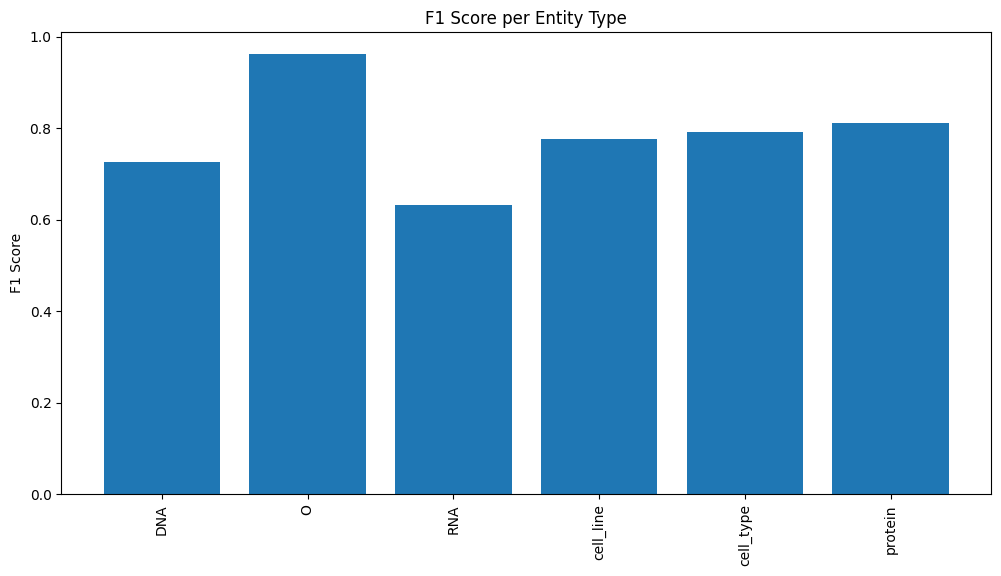

In [30]:
report = classification_report(y_true, y_pred, output_dict=True)

classes = list(report.keys())[:-3]
f1_scores = [report[c]['f1-score'] for c in classes]

plt.figure(figsize=(12,6))
plt.bar(classes, f1_scores)
plt.xticks(rotation=90)
plt.title("F1 Score per Entity Type")
plt.ylabel("F1 Score")
plt.show()

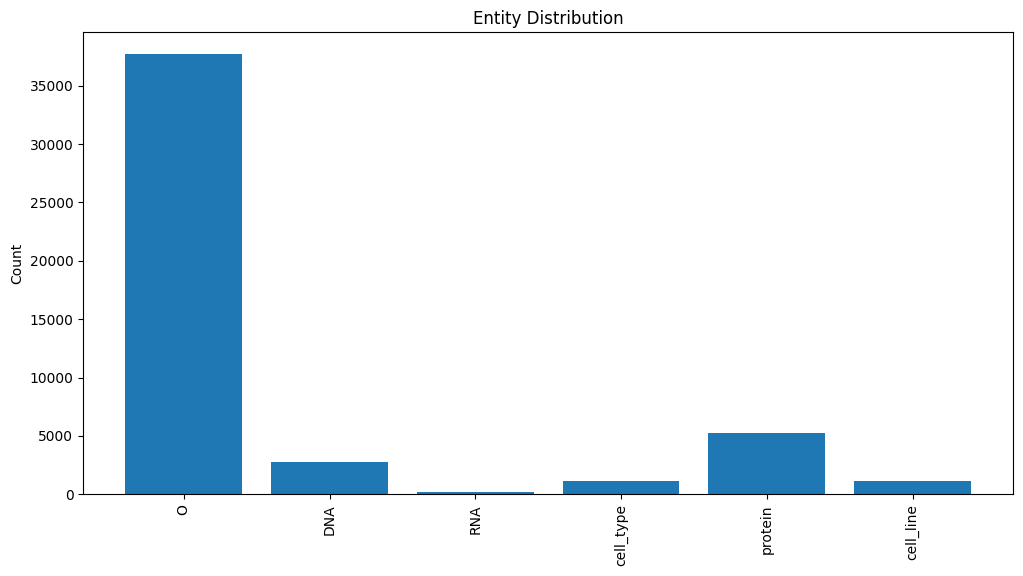

In [31]:
from collections import Counter

entity_counts = Counter(y_true)

plt.figure(figsize=(12,6))
plt.bar(entity_counts.keys(), entity_counts.values())
plt.xticks(rotation=90)
plt.title("Entity Distribution")
plt.ylabel("Count")
plt.show()

In [60]:
def print_final_entities(sample, models):
    tokens = sample["tokens"]
    
    print("="*60)
    print("TOKENS:\n", tokens)

    true_entities = get_true_spans(sample)
    print("\nTRUE ENTITIES:")
    for e in true_entities:
        print(e)

    pred_entities = combine_all_layers(tokens, models)
    
    print("\nPREDICTED ENTITIES:")
    if len(pred_entities) == 0:
        print("No entities predicted")
    else:
        for e in pred_entities:
            print(e)
    
    print("="*60)

In [73]:
print_final_entities(test_data[10], models)

TOKENS:
 ['Employing', 'the', 'EBV-transformed', 'human', 'B', 'cell', 'line', 'SKW6.4', ',', 'we', 'demonstrate', 'that', 'platelet-activating', 'factor', 'significantly', 'alters', 'membrane', 'phospholipid', 'metabolism', 'indicated', 'by', 'the', 'incorporation', 'of', '32P', 'into', 'phosphatidylcholine', ',', 'phosphatidylinositol', ',', 'and', 'phosphatidic', 'acid', 'but', 'not', 'significantly', 'into', 'phosphatidylethanolamine', 'at', 'concentrations', 'ranging', 'from', '10(-9)', 'to', '10(-6)', 'M.']

TRUE ENTITIES:
{'text': 'SKW6.4', 'start': 7, 'end': 8, 'type': 'cell_line'}
{'text': 'human B cell line', 'start': 3, 'end': 7, 'type': 'cell_line'}
{'text': 'EBV-transformed human B cell line', 'start': 2, 'end': 7, 'type': 'cell_line'}
{'text': 'platelet-activating factor', 'start': 12, 'end': 14, 'type': 'protein'}

PREDICTED ENTITIES:
{'text': 'EBV-transformed human B cell line', 'start': 2, 'end': 7, 'type': 'cell_line', 'layer': 1}
{'text': 'SKW6.4', 'start': 7, 'end':